In [1]:
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
from datetime import datetime
import plotly.express as px
import pandas as pd
import json
import os


In [2]:
data_dir = "./data"
raw_dir = os.path.join(data_dir, "raw")
session_dir = os.path.join(raw_dir, "CarpeDiem-20-05-2025")
gameplay_dir = os.path.join(session_dir, "Gameplay")
traces_path = os.path.join(gameplay_dir, "traces.ndjson")


In [ ]:
with open(traces_path, "r", encoding="utf-8") as f:
	print(repr(f.read()[:200]))
	

'{"actor":{"account":{"name":"682b4a72c76d2e0023ed4d05_igbm","homePage":"https://simva-beta.e-ucm.es"}},"result":{"score":{"scaled":1},"completion":true,"extensions":{"https://w3id.org/xapi/seriousgame'


In [4]:
df = pd.read_json(traces_path, lines=True)
display(df)


,actor,result,stored,authority,verb,context,id,version,timestamp,object
0,{'account': {'name': '682b4a72c76d2e0023ed4d05...,"{'score': {'scaled': 1}, 'completion': True, '...",2025-05-19T18:06:04.467Z,"{'name': '682b4a72c76d2e0023ed4d05_igbm', 'hom...","{'display': {'en-US': 'completed'}, 'id': 'htt...",{'contextActivities': {'category': [{'id': 'ht...,a1767d01-1679-47eb-bf2e-f764318774b0,1.0.2,2025-05-19 18:06:01.253000+00:00,"{'definition': {'name': {'en-US': 'quest'}, 'd..."
1,{'account': {'name': '682b4a72c76d2e0023ed4d05...,{'extensions': {'https://w3id.org/xapi/serious...,2025-05-19T18:06:04.467Z,"{'name': '682b4a72c76d2e0023ed4d05_igbm', 'hom...","{'display': {'en-US': 'interacted'}, 'id': 'ht...",{'contextActivities': {'category': [{'id': 'ht...,9e680484-2ae7-40cc-9bac-94d72d4005fe,1.0.2,2025-05-19 18:06:01.190000+00:00,"{'definition': {'name': {'en-US': 'item'}, 'de..."
2,{'account': {'name': '682b4a72c76d2e0023ed4d05...,{'extensions': {'https://w3id.org/xapi/serious...,2025-05-19T18:06:04.467Z,"{'name': '682b4a72c76d2e0023ed4d05_igbm', 'hom...","{'display': {'en-US': 'accessed'}, 'id': 'http...",{'contextActivities': {'category': [{'id': 'ht...,dad6dc45-daf1-4c0b-9394-888c87d781db,1.0.2,2025-05-19 18:06:00.706000+00:00,"{'definition': {'name': {'en-US': 'screen'}, '..."
3,{'account': {'name': '682b4a72c76d2e0023ed4d05...,{'extensions': {'https://w3id.org/xapi/serious...,2025-05-19T18:06:04.467Z,"{'name': '682b4a72c76d2e0023ed4d05_igbm', 'hom...","{'display': {'en-US': 'interacted'}, 'id': 'ht...",{'contextActivities': {'category': [{'id': 'ht...,c634faaf-e0ec-415a-b589-2084fd6349ba,1.0.2,2025-05-19 18:06:00.647000+00:00,"{'definition': {'name': {'en-US': 'item'}, 'de..."
4,{'account': {'name': '682b4a72c76d2e0023ed4d05...,{'extensions': {'https://w3id.org/xapi/serious...,2025-05-19T18:06:04.467Z,"{'name': '682b4a72c76d2e0023ed4d05_igbm', 'hom...","{'display': {'en-US': 'interacted'}, 'id': 'ht...",{'contextActivities': {'category': [{'id': 'ht...,803e7efd-d2c5-4711-bf03-c0beca736371,1.0.2,2025-05-19 18:05:59.422000+00:00,{'definition': {'name': {'en-US': 'game-object...
...,...,...,...,...,...,...,...,...,...,...
48451,{'account': {'name': '682b4a41c76d2e0023ed4b24...,{'extensions': {'https://w3id.org/xapi/serious...,2025-05-20T10:35:59.060Z,"{'name': '682b4a41c76d2e0023ed4b24_dzyu', 'hom...","{'display': {'en-US': 'initialized'}, 'id': 'h...",{'contextActivities': {'category': [{'id': 'ht...,b41fd951-2128-4e7e-a129-2acf43c2986a,1.0.2,2025-05-20 10:35:36.835000+00:00,{'definition': {'name': {'en-US': 'story-node'...
48452,{'account': {'name': '682b4a41c76d2e0023ed4b24...,"{'score': {'scaled': 1}, 'completion': True, '...",2025-05-20T10:35:59.060Z,"{'name': '682b4a41c76d2e0023ed4b24_dzyu', 'hom...","{'display': {'en-US': 'completed'}, 'id': 'htt...",{'contextActivities': {'category': [{'id': 'ht...,ef28c294-3f9e-4b45-bf2b-d7f59fd70815,1.0.2,2025-05-20 10:35:36.835000+00:00,{'definition': {'name': {'en-US': 'story-node'...
48453,{'account': {'name': '682b4a41c76d2e0023ed4b24...,{'extensions': {'https://w3id.org/xapi/serious...,2025-05-20T10:35:59.060Z,"{'name': '682b4a41c76d2e0023ed4b24_dzyu', 'hom...","{'display': {'en-US': 'initialized'}, 'id': 'h...",{'contextActivities': {'category': [{'id': 'ht...,0719bf95-523a-4960-8cc1-e266e8ac042a,1.0.2,2025-05-20 10:35:36.267000+00:00,{'definition': {'name': {'en-US': 'story-node'...
48454,{'account': {'name': '682b4a41c76d2e0023ed4b24...,"{'score': {'scaled': 1}, 'completion': True, '...",2025-05-20T10:35:59.060Z,"{'name': '682b4a41c76d2e0023ed4b24_dzyu', 'hom...","{'display': {'en-US': 'completed'}, 'id': 'htt...",{'contextActivities': {'category': [{'id': 'ht...,32a31dc9-2598-4de5-bbfa-c9e4ec7bd8fc,1.0.2,2025-05-20 10:35:36.267000+00:00,{'definition': {'name': {'en-US': 'story-node'...


In [ ]:
traces = []
invalid_count = 0

with open(traces_path, "r", encoding="utf-8") as f:
	for line in f:
		line = line.strip()
		if line:
			try:
				traces.append(json.loads(line))
			except json.JSONDecodeError:
				invalid_count += 1

print("Total valid traces:", len(traces))
print("Total invalid traces:", invalid_count)


Total valid traces: 48456
Total invalid traces: 0


In [6]:
GAME_START_OBJ_ID = "https://w3id.org/xapi/seriousgames/activity-types/serious-game/GameStart"
GAME_END_OBJ_ID = "https://w3id.org/xapi/seriousgames/activity-types/serious-game/GameEnd"
GENDER_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Gender"
SEXUALITY_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Sexuality"


In [ ]:
def parse_time(t):
	return datetime.fromisoformat(t.replace("Z", "+00:00"))


traces_sorted = sorted(
	traces,
	key=lambda t: parse_time(t.get("timestamp", "1970-01-01T00:00:00Z"))
)

user_state = defaultdict(lambda: {
	"started": False,
	"ended": False
})

first_session_traces = []

for trace in traces_sorted:
	user = trace.get("actor", {}).get("account", {}).get("name")
	if user:
		obj_id = trace.get("object", {}).get("id", "")
		state = user_state[user]

		if obj_id == GAME_START_OBJ_ID:
			if not state["started"]:
				state["started"] = True
				first_session_traces.append(trace)
				
		elif obj_id == GAME_END_OBJ_ID:
			if state["started"] and not state["ended"]:
				state["ended"] = True
				first_session_traces.append(trace)

		else:
			if state["started"] and not state["ended"]:
				first_session_traces.append(trace)

print(len(first_session_traces))


48072


In [ ]:
valid_users = {
	user for user, state in user_state.items()
	if state["started"] and state["ended"]
}

print("Users who completed first session:", len(valid_users))


Users who completed first session: 49


In [ ]:
filtered_traces = [
	trace for trace in first_session_traces
	if trace.get("actor", {}).get("account", {}).get("name") in valid_users
]

print("Filtered traces:", len(filtered_traces))


Filtered traces: 45913


In [ ]:
start_counts = Counter()
end_counts = Counter()

for trace in filtered_traces:
	user = trace["actor"]["account"]["name"]
	obj_id = trace.get("object", {}).get("id", "")

	if obj_id == GAME_START_OBJ_ID:
		start_counts[user] += 1
	elif obj_id == GAME_END_OBJ_ID:
		end_counts[user] += 1

print("Max starts per user:", max(start_counts.values()))
print("Max ends per user:", max(end_counts.values()))


Max starts per user: 1
Max ends per user: 1


In [ ]:
users = set()

user_profile = defaultdict(lambda: {
	"gender": None,
	"sexuality": None,
	"starts": 0
})

for trace in filtered_traces:
	user = trace.get("actor", {}).get("account", {}).get("name")
	if user:
		users.add(user)

		result = trace.get("result", {})
		extensions = result.get("extensions", {}) or {}
		
		if user_profile[user]["gender"] is None:
			user_profile[user]["gender"] = extensions.get(GENDER_EXT_ID)
		
		if user_profile[user]["sexuality"] is None:
			user_profile[user]["sexuality"] = extensions.get(SEXUALITY_EXT_ID)

		obj_id = trace.get("object", {}).get("id", "")

		if obj_id == GAME_START_OBJ_ID:
			user_profile[user]["starts"] += 1

print("Total users:", len(users))

played_more = [user for user, data in user_profile.items() if data["starts"] > 1]
print("Users who have played more than once:", played_more)
# print(user_profile)


Total users: 49
Users who have played more than once: []


In [12]:
df = pd.DataFrame.from_dict(user_profile, orient="index").reset_index()
df.rename(columns={"index": "user"}, inplace=True)

print(df.head())


                            user  gender     sexuality  starts
0  682b4a72c76d2e0023ed4d05_igbm  female  heterosexual       1
1  682b4a41c76d2e0023ed4b24_dmyj  female    homosexual       1
2  682b4a72c76d2e0023ed4d05_agog    male  heterosexual       1
3  682b4a41c76d2e0023ed4b24_sxif    male    homosexual       1
4  682b4a41c76d2e0023ed4b24_msry    male  heterosexual       1


sexuality  heterosexual  homosexual
gender                             
female                8          18
male                 10          13


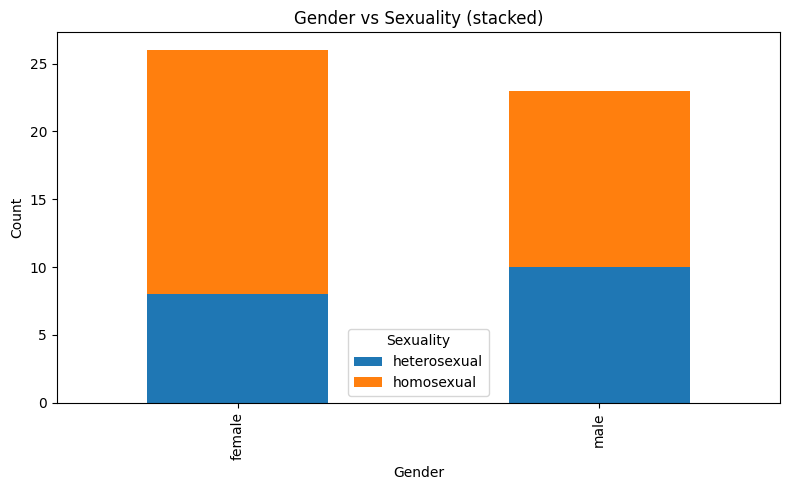

In [13]:
cross = pd.crosstab(df["gender"], df["sexuality"])

print(cross)

cross.plot(kind="bar", stacked=True, figsize=(8, 5))

plt.title("Gender vs Sexuality (stacked)")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.legend(title="Sexuality")
plt.tight_layout()
plt.show()


In [14]:
NODE_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Node"
RESPONSE_EXT_ID = "https://w3id.org/xapi/seriousgame/extensions/Response"
CHOICE_OBJ_ID = "https://w3id.org/xapi/seriousgames/activity-types/dialog-tree/OptionSelect"


In [39]:
node_counts = defaultdict(int)
node_response_counts = defaultdict(Counter)

for trace in filtered_traces:
	obj_id = trace.get("object", {}).get("id", "")
	
	if obj_id == CHOICE_OBJ_ID:
		extensions = trace.get("result", {}).get("extensions", {}) or {}

		node = extensions.get(NODE_EXT_ID)
		response = extensions.get(RESPONSE_EXT_ID)

		if node:
			node_counts[node] += 1

		if node and response:
			node_response_counts[node][response] += 1
			
print(len(node_counts))


53


In [40]:
rows = []

for node in node_counts:
	rows.append({
		"node": node,
		"total_selections": node_counts[node],
		"unique_choices": len(node_response_counts[node])
	})

df_nodes = pd.DataFrame(rows)

display(df_nodes.head())


,node,total_selections,unique_choices
0,Scene1Classroom.part2.thanks,58,3
1,Scene1Lunch1.main.choices,56,2
2,Scene1Lunch1.phone.choices,54,1
3,Scene1Bedroom1.computer1.choices,54,2
4,Scene1Bedroom1.computer1.choices2,54,2


In [41]:
most_chosen = {}

for node, counter in node_response_counts.items():
	option, count = counter.most_common(1)[0]
	most_chosen[node] = {
		"option": option,
		"count": count
	}

for node, data in most_chosen.items():
	print(node, "->", data["option"])
	

Scene1Classroom.part2.thanks -> Igualmente, encantada de conocerte *sonríes*.
Scene1Lunch1.main.choices -> Contarles sobre mi día.
Scene1Lunch1.phone.choices -> Mandar la foto de Toni y Mila.
Scene1Bedroom1.computer1.choices -> Contestar amablemente.
Scene1Bedroom1.computer1.choices2 -> Su perrita.
Scene1Bedroom1.computer2.root -> Un par de años.
Scene1Bedroom1.computer2.choices2 -> 2º de la ESO
Scene1Bedroom1.computer2.choices3 -> Me voy ya, que es tarde
Scene1Bedroom1.bed.goToSleep -> Sí.
Scene1Bedroom2.computer.choices -> No contarle mi día.
Scene1Bedroom2.computer.choices2 -> ¿Estás bien?
Scene1Bedroom2.computer.choices3 -> Irme a la cama.
Scene1Bedroom2.bed.goToSleep -> Sí.
Scene2Break.part2.choice -> ¡De una!
Scene2Bedroom.computer.reply -> Responder.
Scene2Bedroom.phone.choices -> Bueno, me voy a dormir.
Scene2Bedroom.bed.goToSleep -> Sí.
Scene3Break.conversation1.choices -> Seguir escuchando.
Scene3Break.conversation2.choices3 -> Sobre el profesor...
Scene3Bedroom.main.choices 

In [44]:
rows = []

for node, counter in node_response_counts.items():
    option, count = counter.most_common(1)[0]
    total = sum(counter.values())

    rows.append({
        "node": node,
        "most_chosen": option,
        "count": count,
        "total": total,
    })

df_most = pd.DataFrame(rows)
df_most["short_node"] = df_most["node"].apply(lambda x: x.split(".")[-1])
df_most["percentage"] = (df_most["count"] / df_most["total"] * 100).round(2)

TEXT_LENGTH = 35

df_most["short_option"] = df_most["most_chosen"].apply(
    lambda x: x if len(x) <= TEXT_LENGTH else x[:TEXT_LENGTH] + "..."
)

display(df_most.head())


,node,most_chosen,count,total,short_node,percentage,short_option
0,Scene1Classroom.part2.thanks,"Igualmente, encantada de conocerte *sonríes*.",31,58,thanks,53.45,"Igualmente, encantada de conocerte ..."
1,Scene1Lunch1.main.choices,Contarles sobre mi día.,54,56,choices,96.43,Contarles sobre mi día.
2,Scene1Lunch1.phone.choices,Mandar la foto de Toni y Mila.,54,54,choices,100.00,Mandar la foto de Toni y Mila.
3,Scene1Bedroom1.computer1.choices,Contestar amablemente.,39,54,choices,72.22,Contestar amablemente.
4,Scene1Bedroom1.computer1.choices2,Su perrita.,48,54,choices2,88.89,Su perrita.


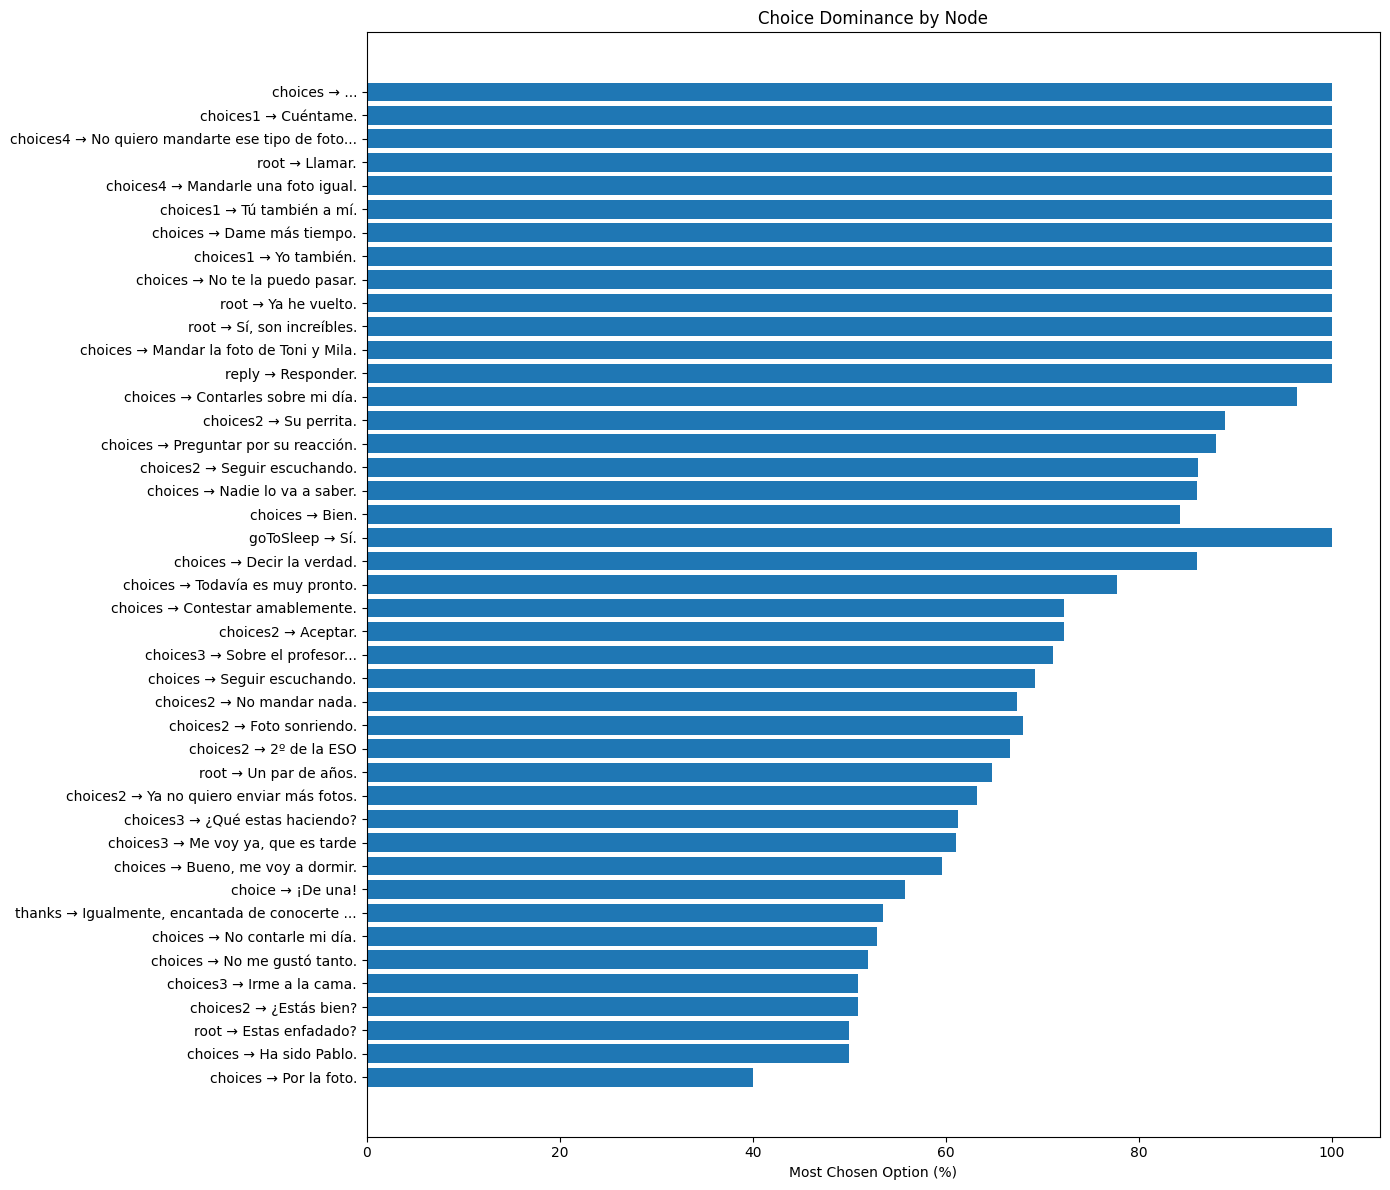

In [45]:
df_plot = df_most.sort_values("percentage")

labels = df_plot["short_node"] + " → " + df_plot["short_option"]

plt.figure(figsize=(14, 12))

plt.barh(labels, df_plot["percentage"])

plt.xlabel("Most Chosen Option (%)")
plt.title("Choice Dominance by Node")

plt.tight_layout()
plt.show()


In [46]:
target_nodes = [
	"Scene1Bedroom1.computer2.choices2", 
	"Scene1Lunch1.main.choices", 
	"Scene4Garage.photo.choices", 
	"Scene4Garage.interruption.choices", 
	"Scene4Bedroom.phone.choices", 
	"Scene5Bedroom.phone.choices2", 
	"Scene5Livingroom.choices", 
	"Scene6Bedroom.phone.choices2", 
	"Scene6BedroomRouteA1.phone.choices2", 
	"Scene6LunchRouteB.interruption.choices" 
]


In [51]:
node_response_counts = defaultdict(Counter)

for trace in filtered_traces:
	obj_id = trace.get("object", {}).get("id", "")

	if obj_id == CHOICE_OBJ_ID:
		extensions = trace.get("result", {}).get("extensions", {}) or {}

		node = extensions.get(NODE_EXT_ID)
		response = extensions.get(RESPONSE_EXT_ID)

		if node in target_nodes and response:
			node_response_counts[node][response] += 1
			
print(len(node_response_counts))
			

10


In [61]:
rows = []

for node in target_nodes:
	total = sum(node_response_counts[node].values())

	for option, count in node_response_counts[node].items():
		rows.append({
			"node": node,
			"option": option,
			"count": count,
			"total": total
		})

df_nodes = pd.DataFrame(rows)

df_nodes["percentage"] = df_nodes["count"] / df_nodes["total"]

# Columnas usadas para ordenar --> "node", "percentage"
# Orden de cada columna --> "node" (ascendente), "percentage" (descendente)
# inplace=True --> modifica df_nodes directamente
df_nodes.sort_values(["node", "percentage"], ascending=[True, False], inplace=True)

display(df_nodes)


,node,option,count,total,percentage
2,Scene1Bedroom1.computer2.choices2,2º de la ESO,36,54,0.666667
1,Scene1Bedroom1.computer2.choices2,4º de la ESO,12,54,0.222222
0,Scene1Bedroom1.computer2.choices2,3º de la ESO,4,54,0.074074
3,Scene1Bedroom1.computer2.choices2,1º de la ESO,2,54,0.037037
4,Scene1Lunch1.main.choices,Contarles sobre mi día.,54,56,0.964286
5,Scene1Lunch1.main.choices,No contarles sobre mi día.,2,56,0.035714
10,Scene4Bedroom.phone.choices,Por la foto.,20,50,0.400000
11,Scene4Bedroom.phone.choices,Prefiero no hablar de ello.,19,50,0.380000
12,Scene4Bedroom.phone.choices,Por nuestra relación.,11,50,0.220000
9,Scene4Garage.interruption.choices,Nadie lo va a saber.,43,50,0.860000


In [62]:
fig = px.bar(
	df_nodes,
	x="percentage",
	y="node",
	color="node",
	orientation="h",
	hover_data={
		"option": True,
		"percentage": ":.2f",
		"node": False
	},
	title="Choice Distribution per Node"
)

fig.update_layout(
	yaxis_title="",
	xaxis_title="Percentage",
	height=900,
	showlegend=False
)

fig.update_xaxes(range=[0, 1])

fig.show()
